# Import


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re

import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.covariance import LedoitWolf

from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
#plt.style.use('seaborn-v0_8-darkgrid')
from dashboard import PortfolioDashboardVisualizer
import cvxpy as cp


import QuantLib as ql
from functools import lru_cache

from finance import get_calendar, COUNTRY_DEFAULT_FREQ_MAP

from signal_model import (
    SignalConfig,
    compute_roll_bp_1m,
    orthogonalize_roll_vs_carry,
    apply_roll_to_signal,
    estimate_expected_returns_from_long,
)

import warnings

warnings.filterwarnings(
    "ignore",
    message="Values in x were outside bounds during a minimize step, clipping to bounds",
    category=RuntimeWarning,
)



## Helpers QuantLib

In [2]:
@lru_cache(maxsize=None)
def _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso):
    """
    Construit et cache un FixedRateBond QuantLib + liste des cashflows (dates/amounts).
    Face = 100, settlementDays=0 (carry calculé "trade-date", simple et stable).
    """
    cal = get_calendar(country_iso)

    daycount = ql.ActualActual(ql.ActualActual.ISMA)

    issue_ql = ql.Date(issue_date.day, issue_date.month, issue_date.year)
    mat_ql   = ql.Date(maturity_date.day, maturity_date.month, maturity_date.year)

    frequency = {1: ql.Annual, 2: ql.Semiannual, 4: ql.Quarterly}.get(int(freq), ql.Semiannual)

    schedule = ql.Schedule(
        issue_ql,
        mat_ql,
        ql.Period(frequency),
        cal,
        ql.Following,
        ql.Following,
        ql.DateGeneration.Backward,
        False,
    )

    face = 100.0
    bond = ql.FixedRateBond(0, face, schedule, [float(coupon_dec)], daycount)

    cfs = [(cf.date(), float(cf.amount())) for cf in bond.cashflows() if isinstance(cf, ql.Coupon)]
    cfs.sort(key=lambda x: x[0])

    return bond, cfs


def _compute_carry_for_isin(df_isin):
    """
    carry journalier (unité "return" / notional) = (Δaccrued + coupons payés) / 100
    sur l'intervalle (t_{k-1}, t_k].
    """
    df = df_isin.sort_values("time_stamp").copy()

    # Si metadata manquante, on retourne sur l'ancienne approximation
    if (df["issue_date"].isna().all() or df["maturity_date"].isna().all() or df["coupon_dec"].isna().all()):
        df["pnl_carry"] = (df["price"] / 100.0) * df["y_dec"] / 252.0
        return df

    issue_date    = df["issue_date"].iloc[0]
    maturity_date = df["maturity_date"].iloc[0]
    coupon_dec    = float(df["coupon_dec"].iloc[0])
    freq          = int(df["cpn_freq"].iloc[0])
    country_iso   = df["country_iso"].iloc[0]

    
    bond, cfs = _build_bond(issue_date, maturity_date, coupon_dec, freq, country_iso)

    cf_dates = [d for d, _ in cfs]
    cf_amts  = [a for _, a in cfs]

    carry = np.zeros(len(df), dtype=float)

    prev_ql = None
    accrued_prev = None
    k = 0  # pointeur cashflows

    for i, ts in enumerate(df["time_stamp"].tolist()):
        d = ql.Date(ts.day, ts.month, ts.year)

        accrued = float(bond.accruedAmount(d))  # en currency units sur face=100

        if prev_ql is None:
            carry[i] = 0.0
            # on ignore tout cashflow <= première date
            while k < len(cf_dates) and cf_dates[k] <= d:
                k += 1
        else:
            coupons = 0.0
            # ajoute les cashflows dans (prev_ql, d]
            while k < len(cf_dates) and cf_dates[k] <= d:
                coupons += cf_amts[k]
                k += 1

            carry_amount_px = (accrued - accrued_prev) + coupons  # "price points" sur base 100
            carry[i] = carry_amount_px / 100.0                   # -> return / notional

        prev_ql = d
        accrued_prev = accrued

    df["pnl_carry"] = carry
    return df


In [3]:
data = pd.read_csv("data/benchmark_mids_cs.csv")

data["time_stamp"] = pd.to_datetime(data["time_stamp"])

data = data.sort_values(["isin", "time_stamp"])

# Keep the last observation per day per ISIN
data = data.groupby(["isin", data["time_stamp"].dt.date], as_index=False).last()
data["time_stamp"] = pd.to_datetime(data["time_stamp"].dt.date)
print(data.shape)
data.head()

(26622, 10)


,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961


In [4]:

mid_bonds_close = pd.read_csv("data/mid_bonds_close_it_de_fr.csv")
mid_bonds_close.head()

,date,isin,yield
0,2023-11-09 00:00:00+00:00,IT0005445306,3.8200
1,2023-12-07 00:00:00+00:00,DE0001102564,2.0770
2,2023-12-22 00:00:00+00:00,FR0014004J31,2.9480
3,2023-11-24 00:00:00+00:00,DE0001135226,2.6785
4,2023-11-30 00:00:00+00:00,DE0001030559,0.2970


## Chargement des coupons par bond


In [5]:
meta = pd.read_csv("data/metadata_bonds.csv")

meta["issue_date"] = pd.to_datetime(meta["issue_date"], errors="coerce")
meta["maturity_date"] = pd.to_datetime(meta["maturity_date"], errors="coerce")

# coupon dans le fichier en %
meta["coupon_dec"] = pd.to_numeric(meta["coupon"], errors="coerce") / 100.0
meta["cpn_freq"] = pd.to_numeric(meta["cpn_freq"], errors="coerce")

meta = meta[["isin", "issue_date", "maturity_date", "coupon_dec", "cpn_freq"]].drop_duplicates("isin")

data = data.merge(meta, on="isin", how="left")

#on ajoute ça pour éviter les problèmes des NULL dans la fréquence de coupon dans la bdd donnée et bien garder les coupons à 0
data["cpn_freq"] = data["cpn_freq"].fillna(
    data["country_iso"].map(COUNTRY_DEFAULT_FREQ_MAP)
).fillna(2).astype(int)

data.head()



,isin,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,maturity_date,coupon_dec,cpn_freq
0,DE0001102366,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,NaT,NaN,1
1,DE0001102366,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,NaT,NaN,1
2,DE0001102366,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,NaT,NaN,1
3,DE0001102366,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,NaT,NaN,1
4,DE0001102366,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,NaT,NaN,1


# Data Pipeline

In [6]:

# --- Typing & sorting ---
data["time_stamp"] = pd.to_datetime(data["time_stamp"])
data["mat_cat"] = data["mat_cat"].astype(str)

data = (
    data
    .sort_values(["isin", "time_stamp"])
    .reset_index(drop=True)
)

# --- Yield level & changes ---
data["y_dec"] = data["yield"] / 100.0

data["dy"] = (
    data
    .groupby("isin")["y_dec"]
    .diff()
)
data["dy_bp"] = data["dy"] * 1e4

# Carry propre via coupons donnés
bad_isins = [
    "FR001400FYQ4", "IT0005607269", "FR001400PM68", "FR001400HI98",
    "IT0005566408", "IT0005518128", "IT0005521981", "IT0005584849",
    "IT0005560948", "IT0005500068", "IT0005611055", "DE0001135226",
    "DE000BU22056", "IT0005637399", "DE000BU2F009", "IT0005631590",
    "FR001400OHF4", "DE000BU22064", "IT0005657330", "IT0005582421"
]
data = data[~data["isin"].isin(bad_isins)]
try:
    data = data.groupby("isin", group_keys=False).apply(
        _compute_carry_for_isin, include_groups=False
    )
except TypeError:
    data = data.groupby("isin", group_keys=False).apply(_compute_carry_for_isin)


# VERSION 1 : PnL (unité return / notional)
data["pnl_yield"] = -data["dv01"] * data["dy_bp"]
data["pnl_total_unit"] = data["pnl_yield"] + data["pnl_carry"]


# VERSION 2 : RETURN NORMALISÉ DV01 (en bp)
eps = 1e-12
data["carry_bp_equiv"] = np.where(
    np.abs(data["dv01"]) > eps,
    data["pnl_carry"] / data["dv01"],
    0.0,
)
data["ret_total_per_dv01"] = -data["dy_bp"] + data["carry_bp_equiv"]

data.head()

,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,...,NaN,1,0.005400,NaN,NaN,0.000022,NaN,NaN,0.023346,NaN
1,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079


In [7]:

"""
data_roll = data.copy()

# 1) compute roll-down (bp, horizon 1M)
data_roll = compute_roll_bp_1m(
    data_roll,
    date_col="time_stamp",
    country_col="country_iso",
    maturity_col="remaining_maturity",
    curve_node_col="mat_cat",
    yield_col="yield",
    yield_in_percent=True,      # ton yield est en %
    horizon_months=1,
    out_col="roll_bp_1m",
    clip_bp=25.0
)

# 2) orthogonalize roll vs carry
data_roll = orthogonalize_roll_vs_carry(
    data_roll,
    date_col="time_stamp",
    carry_col="carry_bp_equiv",
    roll_col="roll_bp_1m",
    out_col="roll_ortho_bp"
)

# 3) sanity check quant
print(data_roll["roll_bp_1m"].describe())
print(data_roll[["carry_bp_equiv", "roll_bp_1m", "roll_ortho_bp"]].corr())
"""


'\ndata_roll = data.copy()\n\n# 1) compute roll-down (bp, horizon 1M)\ndata_roll = compute_roll_bp_1m(\n    data_roll,\n    date_col="time_stamp",\n    country_col="country_iso",\n    maturity_col="remaining_maturity",\n    curve_node_col="mat_cat",\n    yield_col="yield",\n    yield_in_percent=True,      # ton yield est en %\n    horizon_months=1,\n    out_col="roll_bp_1m",\n    clip_bp=25.0\n)\n\n# 2) orthogonalize roll vs carry\ndata_roll = orthogonalize_roll_vs_carry(\n    data_roll,\n    date_col="time_stamp",\n    carry_col="carry_bp_equiv",\n    roll_col="roll_bp_1m",\n    out_col="roll_ortho_bp"\n)\n\n# 3) sanity check quant\nprint(data_roll["roll_bp_1m"].describe())\nprint(data_roll[["carry_bp_equiv", "roll_bp_1m", "roll_ortho_bp"]].corr())\n'

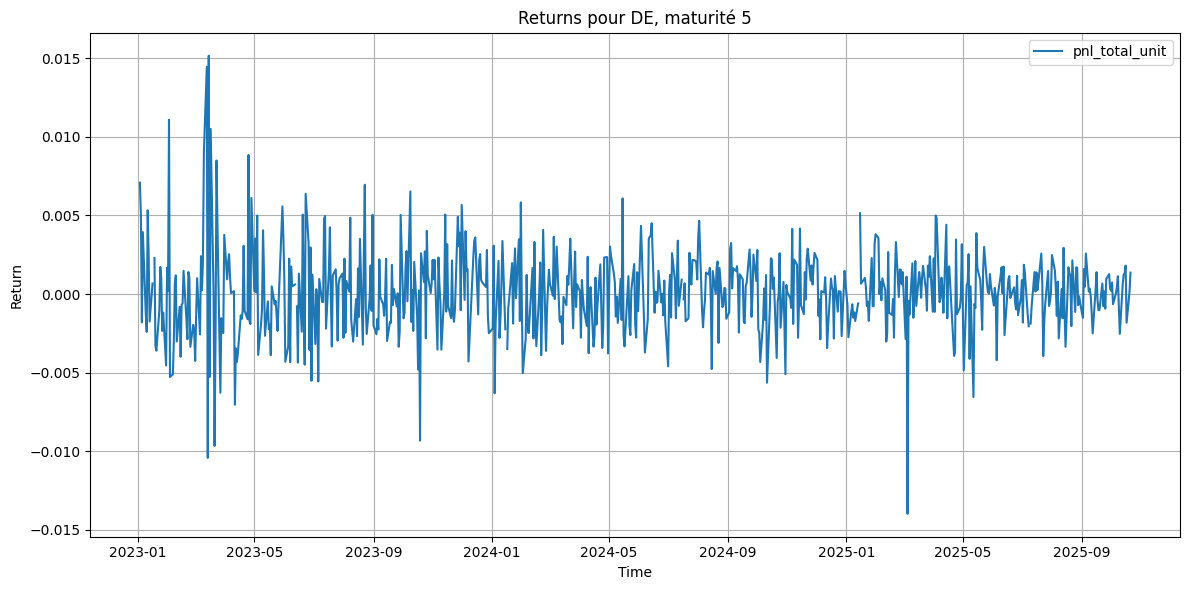

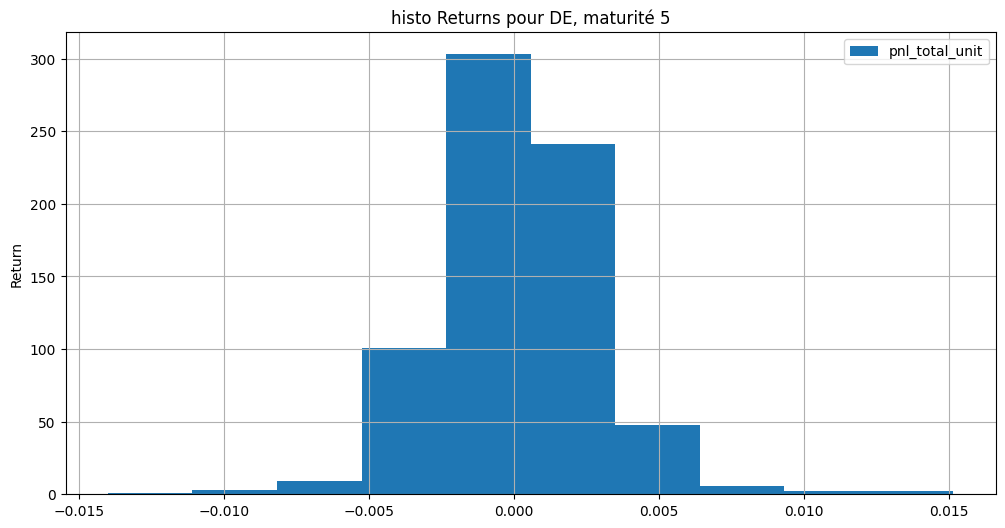

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Variables à modifier facilement
# -----------------------------
country = "DE"                # Pays à filtrer
maturity = "5"                # Maturité à filtrer (valeur de mat_cat)
return_col1 = "ret_total_per_dv01"   # Colonne de return DV01
return_col2 = "pnl_total_unit" # Colonne de coupon quotidien
return_col3 = "pnl_total_unit"    # Colonne de return total

start_date = "2023-01-01"    # Date de début du plot
end_date = "2025-12-31"      # Date de fin du plot

# -----------------------------
# Filtrage du DataFrame
# -----------------------------
df_plot = data.loc[
    (data["country_iso"] == country) &
    (data["mat_cat"] == maturity) &
    (data["time_stamp"] >= pd.to_datetime(start_date)) &
    (data["time_stamp"] <= pd.to_datetime(end_date))
]

# -----------------------------
# Plot avec matplotlib
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(df_plot["time_stamp"], df_plot[return_col2], label=return_col2, linestyle="-")
plt.title(f"Returns pour {country}, maturité {maturity}")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(df_plot[return_col2], label=return_col2)
plt.title(f"histo Returns pour {country}, maturité {maturity}")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

In [9]:

data

,Unnamed: 0,time_stamp,price,yield,country_iso,mat_cat,source,remaining_maturity,dv01,issue_date,...,coupon_dec,cpn_freq,y_dec,dy,dy_bp,pnl_carry,pnl_yield,pnl_total_unit,carry_bp_equiv,ret_total_per_dv01
0,2640,2015-01-01,104.3100,0.5400,DE,10,ref,9.618070,0.000957,NaT,...,NaN,1,0.005400,NaN,NaN,0.000022,NaN,NaN,0.023346,NaN
1,1980,2015-01-02,104.7105,0.4965,DE,10,ref,9.615332,0.000962,NaT,...,NaN,1,0.004965,-0.000435,-4.35,0.000021,0.004183,0.004203,0.021456,4.371456
2,1320,2015-01-05,104.5205,0.5165,DE,10,ref,9.607118,0.000959,NaT,...,NaN,1,0.005165,0.000200,2.00,0.000021,-0.001917,-0.001896,0.022345,-1.977655
3,660,2015-01-06,105.2050,0.4450,DE,10,ref,9.604381,0.000966,NaT,...,NaN,1,0.004450,-0.000715,-7.15,0.000019,0.006904,0.006923,0.019240,7.169240
4,0,2015-01-07,104.8350,0.4835,DE,10,ref,9.601643,0.000961,NaT,...,NaN,1,0.004835,0.000385,3.85,0.000020,-0.003702,-0.003681,0.020921,-3.829079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26417,32815022,2025-10-15,100.6650,3.8270,IT,15,ref,14.959617,0.001120,2025-02-18,...,0.0385,2,0.038270,-0.000254,-2.54,0.000106,0.002845,0.002950,0.094446,2.634446
26418,32832218,2025-10-16,100.9550,3.8010,IT,15,ref,14.956879,0.001124,2025-02-18,...,0.0385,2,0.038010,-0.000260,-2.60,0.000106,0.002922,0.003028,0.094119,2.694119
26419,32849394,2025-10-17,100.5820,3.8343,IT,15,ref,14.954141,0.001119,2025-02-18,...,0.0385,2,0.038343,0.000333,3.33,0.000106,-0.003725,-0.003619,0.094553,-3.235447
26420,32866577,2025-10-20,100.8850,3.8072,IT,15,ref,14.945927,0.001123,2025-02-18,...,0.0385,2,0.038072,-0.000271,-2.71,0.000317,0.003042,0.003359,0.282675,2.992675


In [10]:
#On met data sous le bon format. Ce qu'on veut c'est :
# Date | Finacial product (ex FR_5 pour France bond mat 5) | Return
val1 = "ret_total_per_dv01"
val2 = "pnl_total_unit"

data_completed = data[["time_stamp", "country_iso", "mat_cat", val1, val2, "dv01","maturity_date"]].copy()
data_completed["product"] = data_completed["country_iso"].astype(str) + "_" + data_completed["mat_cat"].astype(str)
data_completed = data_completed.drop(columns=["country_iso", "mat_cat"])
data_completed["time_stamp"] = pd.to_datetime(data_completed["time_stamp"])
dv01_ref = data_completed["dv01"].median()
data_completed.head()

,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,maturity_date,product
0,2015-01-01,NaN,NaN,0.000957,NaT,DE_10
1,2015-01-02,4.371456,0.004203,0.000962,NaT,DE_10
2,2015-01-05,-1.977655,-0.001896,0.000959,NaT,DE_10
3,2015-01-06,7.169240,0.006923,0.000966,NaT,DE_10
4,2015-01-07,-3.829079,-0.003681,0.000961,NaT,DE_10


## Chargement des bid-offer par bond

In [11]:
bo = pd.read_csv("data/bid_offer_CS.csv")  # adapte le nom si besoin
# Harmonise les types
bo["mat_cat"] = bo["mat_cat"].astype(str)

# On définit le product bond simple : "FR_5", "DE_10", etc.
bo["product"] = bo["country_iso"].astype(str) + "_" + bo["mat_cat"].astype(str)

# On agrège par product (médiane par ex. s'il y a plusieurs ISIN dans le bucket)
bond_bidoffer_yield = (
    bo.groupby("product")["q25_spread_yield"]
    .median()
    .rename("bidoffer_yield_bond")
)
bond_bidoffer_yield_bp = bond_bidoffer_yield 
bond_bidoffer_yield.head()


product
AT_10    0.006
AT_15    0.011
AT_2     0.023
AT_20    0.008
AT_3     0.017
Name: bidoffer_yield_bond, dtype: float64

# Ajout spread et curve 

In [12]:
def add_spread_curve(
    data,
    value_col="pnl_total_unit",
    bond_bidoffer_yield=None
):
    """
    Ajoute au format long (time_stamp, product, value_col) :
      - Obligations "outright" : FR_2, DE_10, ...
      - Spreads entre pays à même maturité      : FR_DE_2        (type = spread_country)
      - Curve Spreads intra-pays                : FR_2_5         (type = spread_curve)
      - Butterflies intra-pays                  : FR_fly_2_5_10  (type = butterfly_curve)
      - Box / Différences de pente entre pays   : FR_DE_slope_2_10 (type = slope_diff_country)

    Paramètres
    ----------
    data : DataFrame
        Colonnes attendues : time_stamp, product, value_col
    value_col : str
        Nom de la colonne de return à utiliser
        (ex: "pnl_total_unit" ou "ret_total_per_dv01")
    bond_bidoffer_yield : Series optionnelle
        index = product (ex: "FR_2"), valeurs = bid/offer en yield pour les bonds simples.

    Retour
    ------
    DataFrame long enrichi avec une colonne 'type'
    et 'bid_offer_yield' si disponible.
    """

    df = data.copy()

    # --- Produits originaux ---
    product_type = {p: "bond" for p in df["product"].unique()}

    # --- Extraction pays / maturités ---
    products = df["product"].unique()
    countries = sorted({p.split("_")[0] for p in products})

    def sort_mats(mats):
        try:
            return sorted(mats, key=lambda x: float(x))
        except ValueError:
            return sorted(mats)

    maturities = sort_mats({p.split("_")[1] for p in products})

    # --- Pivot large ---
    wide = (
        df
        .pivot(index="time_stamp", columns="product", values=value_col)
        .sort_index()
    )

    # --- Bid / offer par produit ---
    bidoffer_product = {}
    if bond_bidoffer_yield is not None:
        for p in wide.columns:
            if p in bond_bidoffer_yield.index:
                bidoffer_product[p] = bond_bidoffer_yield.loc[p]

    # ============================
    # 1) SPREADS ENTRE PAYS
    # ============================
    for mat in maturities:
        prods_mat = [f"{c}_{mat}" for c in countries if f"{c}_{mat}" in wide.columns]

        for i in range(len(prods_mat)):
            for j in range(i + 1, len(prods_mat)):
                p1, p2 = prods_mat[i], prods_mat[j]
                c1, c2 = p1.split("_")[0], p2.split("_")[0]

                spread_name = f"{c1}_{c2}_{mat}"
                if spread_name not in wide.columns:
                    wide[spread_name] = wide[p1] - wide[p2]
                    product_type[spread_name] = "spread_country"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2):
                            half_sum = 0.5 * (bo1 + bo2)
                            bidoffer_product[spread_name] = (
                                half_sum * bid_offer_multiplier["spread"]
                            )

    # ============================
    # 2) SPREADS DE COURBE
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c)):
            for j in range(i + 1, len(mats_c)):
                m1, m2 = mats_c[i], mats_c[j]
                p1, p2 = f"{c}_{m1}", f"{c}_{m2}"

                if p1 in wide.columns and p2 in wide.columns:
                    spread_name = f"{c}_{m1}_{m2}"
                    if spread_name not in wide.columns:
                        wide[spread_name] = wide[p1] - wide[p2]
                        product_type[spread_name] = "spread_curve"

                        if bond_bidoffer_yield is not None:
                            bo1 = bidoffer_product.get(p1, np.nan)
                            bo2 = bidoffer_product.get(p2, np.nan)
                            if np.isfinite(bo1) and np.isfinite(bo2):
                                half_sum = 0.5 * (bo1 + bo2)
                                bidoffer_product[spread_name] = (
                                    half_sum * bid_offer_multiplier["curve"]
                                )

    # ============================
    # 3) BUTTERFLIES
    # ============================
    for c in countries:
        mats_c = sort_mats([p.split("_")[1] for p in products if p.startswith(c + "_")])

        for i in range(len(mats_c) - 2):
            m1, m2, m3 = mats_c[i], mats_c[i + 1], mats_c[i + 2]
            p1, p2, p3 = f"{c}_{m1}", f"{c}_{m2}", f"{c}_{m3}"

            if all(p in wide.columns for p in (p1, p2, p3)):
                fly_name = f"{c}_fly_{m1}_{m2}_{m3}"
                if fly_name not in wide.columns:
                    wide[fly_name] = wide[p1] - 2 * wide[p2] + wide[p3]
                    product_type[fly_name] = "butterfly_curve"

                    if bond_bidoffer_yield is not None:
                        bo1 = bidoffer_product.get(p1, np.nan)
                        bo2 = bidoffer_product.get(p2, np.nan)
                        bo3 = bidoffer_product.get(p3, np.nan)
                        if np.isfinite(bo1) and np.isfinite(bo2) and np.isfinite(bo3):
                            half_sum = 0.5 * (bo1 + bo2 + bo3)
                            bidoffer_product[fly_name] = (
                                half_sum * bid_offer_multiplier["fly"]
                            )

    # ============================
    # 4) BOX / SLOPE DIFF
    # ============================
    for idx_low in range(len(maturities) - 1):
        for idx_high in range(idx_low + 1, len(maturities)):
            m_low, m_high = maturities[idx_low], maturities[idx_high]

            for i in range(len(countries)):
                for j in range(i + 1, len(countries)):
                    c1, c2 = countries[i], countries[j]
                    p1_low, p1_high = f"{c1}_{m_low}", f"{c1}_{m_high}"
                    p2_low, p2_high = f"{c2}_{m_low}", f"{c2}_{m_high}"

                    if all(p in wide.columns for p in (p1_low, p1_high, p2_low, p2_high)):
                        slope_name = f"{c1}_{c2}_slope_{m_low}_{m_high}"
                        if slope_name not in wide.columns:
                            wide[slope_name] = (
                                (wide[p1_high] - wide[p1_low]) -
                                (wide[p2_high] - wide[p2_low])
                            )
                            product_type[slope_name] = "slope_diff_country"

                            if bond_bidoffer_yield is not None:
                                bo1_low  = bidoffer_product.get(p1_low,  np.nan)
                                bo1_high = bidoffer_product.get(p1_high, np.nan)
                                bo2_low  = bidoffer_product.get(p2_low,  np.nan)
                                bo2_high = bidoffer_product.get(p2_high, np.nan)

                                if all(np.isfinite(x) for x in [bo1_low, bo1_high, bo2_low, bo2_high]):
                                    half_sum = 0.5 * (bo1_low + bo1_high + bo2_low + bo2_high)
                                    bidoffer_product[slope_name] = (
                                        half_sum * bid_offer_multiplier["box"]
                                    )

    # ============================
    # Retour format long
    # ============================
    long = wide.reset_index().melt(
        id_vars="time_stamp",
        var_name="product",
        value_name=value_col
    )

    long["type"] = long["product"].map(product_type).fillna("unknown")

    if bond_bidoffer_yield is not None:
        bo_series = pd.Series(bidoffer_product)
        long["bid_offer_yield"] = long["product"].map(bo_series)

    return long


In [13]:

bid_offer_multiplier = {
    "fly": 0.25,
    "box": 0.375,
    "spread": 0.5,
    "curve": 0.4,
}

long = add_spread_curve(data_completed,value_col="pnl_total_unit",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long2 = add_spread_curve(data_completed,value_col="ret_total_per_dv01",  bond_bidoffer_yield=bond_bidoffer_yield_bp)
long_dv01 = add_spread_curve(data_completed, value_col="dv01", bond_bidoffer_yield=None)
dv01_by_product = long_dv01.groupby("product")["dv01"].median()

long["ret_total_per_dv01"] = long2["ret_total_per_dv01"]
long.head(10)

long[long["type"].isin(["bond", "spread_country", "spread_curve", "butterfly_curve", "slope_diff_country"])] \
    .groupby("type")["bid_offer_yield"].describe()


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
bond,34920.0,0.008533,0.005476,0.002000,0.004000,0.006000,0.014000,0.020000
butterfly_curve,20952.0,0.002792,0.001402,0.001125,0.001875,0.002125,0.003750,0.005375
slope_diff_country,69840.0,0.006400,0.002084,0.002625,0.004875,0.006562,0.008062,0.010313
spread_country,34920.0,0.004267,0.001948,0.001250,0.002250,0.004250,0.006250,0.007250
spread_curve,69840.0,0.003413,0.001760,0.001000,0.001800,0.003000,0.004600,0.007400


In [14]:
data_completed

,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,maturity_date,product
0,2015-01-01,NaN,NaN,0.000957,NaT,DE_10
1,2015-01-02,4.371456,0.004203,0.000962,NaT,DE_10
2,2015-01-05,-1.977655,-0.001896,0.000959,NaT,DE_10
3,2015-01-06,7.169240,0.006923,0.000966,NaT,DE_10
4,2015-01-07,-3.829079,-0.003681,0.000961,NaT,DE_10
...,...,...,...,...,...,...
26417,2025-10-15,2.634446,0.002950,0.001120,2040-10-01,IT_15
26418,2025-10-16,2.694119,0.003028,0.001124,2040-10-01,IT_15
26419,2025-10-17,-3.235447,-0.003619,0.001119,2040-10-01,IT_15
26420,2025-10-20,2.992675,0.003359,0.001123,2040-10-01,IT_15


In [15]:
long_bond = long[long["type"] == "bond"][["time_stamp", "product", "bid_offer_yield"]]
long_bond = data_completed.merge(long_bond, on=["time_stamp", "product"])
long_bond

,time_stamp,ret_total_per_dv01,pnl_total_unit,dv01,maturity_date,product,bid_offer_yield
0,2015-01-01,NaN,NaN,0.000957,NaT,DE_10,0.003
1,2015-01-02,4.371456,0.004203,0.000962,NaT,DE_10,0.003
2,2015-01-05,-1.977655,-0.001896,0.000959,NaT,DE_10,0.003
3,2015-01-06,7.169240,0.006923,0.000966,NaT,DE_10,0.003
4,2015-01-07,-3.829079,-0.003681,0.000961,NaT,DE_10,0.003
...,...,...,...,...,...,...,...
23201,2025-10-15,2.634446,0.002950,0.001120,2040-10-01,IT_15,0.004
23202,2025-10-16,2.694119,0.003028,0.001124,2040-10-01,IT_15,0.004
23203,2025-10-17,-3.235447,-0.003619,0.001119,2040-10-01,IT_15,0.004
23204,2025-10-20,2.992675,0.003359,0.001123,2040-10-01,IT_15,0.004


# Class Portfolio à date t 

In [16]:

class Portfolio:
    def __init__(
        self,
        data,
        date,
        benchmark="ew",
        long_only=True,
        lamb=0.1,
        rebalancement='ME',
        span=6,
        initial_weights=None,
        initial_positions = None,
        delta=0.1,
        tc_gamma=0.1
        
    ):
        """
        Classe Portfolio : initialise un portefeuille pour optimisation Markowitz
        basé sur des returns DV01-normalisés.

        Paramètres
        ----------
        data : pd.DataFrame
            Historique des produits avec au moins les colonnes :
            'time_stamp', 'product', 'pnl_total_unit', éventuellement 'ret_total_per_dv01'.
        date : datetime-like
            Date de rebalancement / estimation. Seules les données avant cette date sont utilisées.
        benchmark : str, default "ew"
            Nom du benchmark pour comparaison (ex: equal-weighted).
        long_only : bool, default True
            Si True, les poids sont projetés sur le simplexe (pas de short).
        lamb : float, default 1.0
            Paramètre d’aversion au risque λ pour Markowitz : maximise μ'w - λ w'Σw.
        rebalancement : str, default 'ME'
            Fréquence de rebalancement :
            'D' = quotidien, 'W' = hebdomadaire, 'M' = mensuel, 'ME' = fin de mois.
        span : int, default 6
            Demi-vie pour calcul EWMA des retours moyens.
        initial_weights : array-like or None, default None
            Poids initiaux du portefeuille, pour démarrer l’optimisation.
        delta : float, default 0.1
            Paramètre de régularisation / limite de variation de poids.
        tc_gamma : float, default 0.1
            Coefficient de coût de transaction.

        Attributs internes
        ------------------
        self.data : pd.DataFrame
        self.date : pd.Timestamp
        self.benchmark : str
        self.long_only : bool
        self.lamb : float
        self.rebalancement : str
        self.sigma_level : float
        self.span : int
        self.initial_weights : array-like or None
        self.delta : float
        self.tc_gamma : float

        self.returns : pd.DataFrame
            Returns filtrés jusqu'à self.date.
        self.mean_returns : pd.DataFrame or pd.Series
            Moyenne des retours (EWMA).
        self.cov_matrix : pd.DataFrame
            Matrice de covariance des returns.
        self.weights : pd.Series or np.array
            Poids optimisés pour la période courante.
        self.benchmark_weights : pd.Series or np.array
            Poids du benchmark pour comparaison.
        """

        # --- données et date ---
        self.data = data
        self.date = pd.to_datetime(date)
        self.benchmark = benchmark

        # --- paramètres optimisation ---
        self.long_only = long_only
        self.lamb = float(lamb)
        self.rebalancement = rebalancement
        self.span = span
        self.delta = delta
        self.tc_gamma = float(tc_gamma)
        self.initial_weights = initial_weights

        # --- attributs internes ---
        self.returns = None
        self.mean_returns = None
        self.cov_matrix = None
        self.weights = None
        self.benchmark_weights = None

        # --- positions ---
        self.positions = initial_positions

    def get_returns_until(self):
        """Filter returns up to self.date and resample according to rebalancement."""
        R = self.data[self.data["time_stamp"] < self.date].copy()

        # --- resampling selon la fréquence de rebalancement ---
        if hasattr(self, "rebalancement") and self.rebalancement in ["D", "W", "ME"]:
            df_list = []
            for prod, df_prod in R.groupby("product"):
                df_prod = df_prod.set_index("time_stamp").sort_index()
                if self.rebalancement != "D":
                    df_resampled = df_prod["ret_total_per_dv01"].resample(self.rebalancement).sum()
                else:
                    df_resampled = df_prod["ret_total_per_dv01"]
                df_resampled = df_resampled.reset_index()
                df_resampled["product"] = prod
                df_list.append(df_resampled)
            R = pd.concat(df_list, axis=0)
        else:
            # default = daily
            R = R.copy()

        self.returns = R.sort_values(["product", "time_stamp"])


    def estimate_returns(self):
        """EWMA of returns per product, shifted by 1 day to avoid look-ahead."""
        span = self.span

        df = self.returns[["time_stamp", "product", "ret_total_per_dv01"]].copy()
        df = df.sort_values(["product", "time_stamp"])

        df["ret_total_per_dv01"] = (
            df.groupby("product")["ret_total_per_dv01"].shift(1)
        )

        ewma = (
            df.groupby("product")["ret_total_per_dv01"]
            .apply(lambda x: x.ewm(span=span, adjust=False).mean().iloc[-1])
            .reset_index(name="ewma_ret_dv01")
        )

        self.mean_returns = ewma

    def estimate_cov_matrix_Ledoit(self):
        """
        Estimate covariance matrix using Ledoit-Wolf shrinkage.
        Only uses dates where ALL products have data (complete-case analysis).
        """
        panel = self.returns.pivot(
            index="time_stamp",
            columns="product",
            values="ret_total_per_dv01",
        ).sort_index()

        # --- Drop dates with any missing product ---
        panel_clean = panel.dropna(axis=0, how="any")

        if len(panel_clean) < 2:
            # Fallback: not enough overlapping data → diagonal matrix
            import warnings
            warnings.warn(
                f"Only {len(panel_clean)} overlapping dates for covariance at {self.date}. "
                "Using diagonal (variance-only) estimate."
            )
            # Use per-column variance (ignoring NaN) as diagonal
            var = panel.var(skipna=True).fillna(0.0).values
            n = panel.shape[1]
            cov_matrix = np.diag(var)
        else:
            X = panel_clean.values
            lw = LedoitWolf().fit(X)
            cov_matrix = lw.covariance_

        self.cov_matrix = pd.DataFrame(
            cov_matrix,
            columns=panel.columns,
            index=panel.columns,
        )

    def estimate_cov_matrix_factor(self, halflife=63, shrinkage=0.2):
        """
        Factor risk model: country × maturity factors + market factor.
        Σ = B @ F @ B.T + D

        Uses EWMA covariance (time-varying) instead of full-sample Ledoit-Wolf.

        Parameters
        ----------
        halflife : int
            EWMA half-life in days for factor covariance (default 63 ≈ 3 months).
        shrinkage : float
            Shrinkage intensity toward diagonal (0 = sample, 1 = diagonal).
        """

        panel = self.returns.pivot(
            index="time_stamp", columns="product", values="ret_total_per_dv01"
        ).sort_index()
        products = list(panel.columns)
        n_products = len(products)

        # ---- 1) Identify base bonds (factors) ----
        base_pattern = re.compile(r'^([A-Z]{2})_(\d+)$')
        base_bonds = [p for p in products if base_pattern.match(p)]

        if len(base_bonds) < 2:
            import warnings
            warnings.warn("Cannot identify base bonds, falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        factor_idx = {b: i for i, b in enumerate(base_bonds)}
        n_base = len(base_bonds)
        # Total factors = base bonds + 1 market factor
        n_factors = n_base + 1
        market_col = n_base  # last column is market factor

        # ---- 2) Build loading matrix B (n_products × n_factors) ----
        B = np.zeros((n_products, n_factors))

        country_weights = {"DE": 0.30, "FR": 0.25, "IT": 0.25, "SP": 0.20}

        for i, prod in enumerate(products):
            parts = prod.split("_")

            # Bond: "DE_10" → +1 on DE_10
            if base_pattern.match(prod):
                B[i, factor_idx[prod]] = 1.0
                # Also loads on market factor
                country = parts[0]
                B[i, market_col] = country_weights.get(country, 0.25)

            # Butterfly: "DE_fly_2_5_10" → +1, -2, +1
            elif "fly" in parts:
                fly_pos = parts.index("fly")
                country = parts[0]
                mats = parts[fly_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = 1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] = 1.0
                        # Butterfly is market-neutral → no market loading

            # Nesterov butterfly: "DE_Ny_2_5_10"
            elif "Ny" in parts:
                ny_pos = parts.index("Ny")
                country = parts[0]
                mats = parts[ny_pos + 1:]
                if len(mats) == 3:
                    keys = [f"{country}_{m}" for m in mats]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = 1.0
                        B[i, factor_idx[keys[1]]] = -2.0
                        B[i, factor_idx[keys[2]]] = 1.0

            # Slope diff: "FR_DE_slope_2_10"
            elif "slope" in parts:
                slope_pos = parts.index("slope")
                c1, c2 = parts[0], parts[1]
                mats = parts[slope_pos + 1:]
                if len(mats) == 2:
                    m_low, m_high = mats
                    keys = [f"{c1}_{m_low}", f"{c1}_{m_high}", f"{c2}_{m_low}", f"{c2}_{m_high}"]
                    if all(k in factor_idx for k in keys):
                        B[i, factor_idx[keys[0]]] = -1.0
                        B[i, factor_idx[keys[1]]] = 1.0
                        B[i, factor_idx[keys[2]]] = 1.0
                        B[i, factor_idx[keys[3]]] = -1.0

            # Country spread: "FR_DE_2" → +1 FR_2, -1 DE_2
            elif len(parts) == 3 and all(len(p) == 2 and p.isalpha() for p in parts[:2]):
                c1, c2, mat = parts
                p1, p2 = f"{c1}_{mat}", f"{c2}_{mat}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] = 1.0
                    B[i, factor_idx[p2]] = -1.0
                    # Partial market loading (country diff)
                    w1 = country_weights.get(c1, 0.25)
                    w2 = country_weights.get(c2, 0.25)
                    B[i, market_col] = w1 - w2

            # Curve spread: "DE_2_10" → +1 DE_2, -1 DE_10
            elif len(parts) == 3 and len(parts[0]) == 2 and parts[0].isalpha():
                country, m1, m2 = parts
                p1, p2 = f"{country}_{m1}", f"{country}_{m2}"
                if p1 in factor_idx and p2 in factor_idx:
                    B[i, factor_idx[p1]] = 1.0
                    B[i, factor_idx[p2]] = -1.0
                    # Curve spread is duration-neutral → no market loading

        # ---- 3) Build factor return series (including market) ----
        factor_returns_raw = panel[base_bonds].copy()
        factor_returns_clean = factor_returns_raw.dropna(how="any")

        if len(factor_returns_clean) < n_base + 1:
            import warnings
            warnings.warn("Not enough data for factor model, falling back to Ledoit-Wolf")
            return self.estimate_cov_matrix_Ledoit()

        # Market factor: weighted average of base bond returns
        market_return = pd.Series(0.0, index=factor_returns_clean.index)
        total_w = 0
        for bond in base_bonds:
            country = bond.split("_")[0]
            w = country_weights.get(country, 0.25)
            market_return += w * factor_returns_clean[bond]
            total_w += w
        market_return /= total_w

        # Combine: base bonds + market
        factor_matrix = factor_returns_clean.copy()
        factor_matrix["_MARKET_"] = market_return
        factor_vals = factor_matrix.values  # (T × n_factors)
        T = factor_vals.shape[0]

        # ---- 4) EWMA factor covariance ----
        ewma_weights = np.exp(-np.log(2) / halflife * np.arange(T)[::-1])
        ewma_weights /= ewma_weights.sum()

        mu = (ewma_weights[:, None] * factor_vals).sum(axis=0)
        centered = factor_vals - mu
        F = (centered * ewma_weights[:, None]).T @ centered

        # Shrink toward diagonal
        diag_F = np.diag(np.diag(F))
        F = (1 - shrinkage) * F + shrinkage * diag_F

        # Symmetrize
        F = 0.5 * (F + F.T)
        F += 1e-10 * np.eye(n_factors)

        # ---- 5) Product covariance: Σ = B @ F @ B.T + D ----
        Sigma_factor = B @ F @ B.T

        # ---- 6) EWMA idiosyncratic variance ----
        # Predicted returns from factor model
        factor_panel_full = panel[base_bonds].fillna(0).copy()
        factor_panel_full["_MARKET_"] = 0.0
        for bond in base_bonds:
            country = bond.split("_")[0]
            w = country_weights.get(country, 0.25)
            factor_panel_full["_MARKET_"] += w * panel[base_bonds].fillna(0)[bond]
        factor_panel_full["_MARKET_"] /= total_w

        predicted = factor_panel_full.values @ B.T  # (T_full × n_products)
        actual = panel[products].fillna(0).values
        residuals = actual - predicted

        T_full = residuals.shape[0]
        ewma_w_full = np.exp(-np.log(2) / halflife * np.arange(T_full)[::-1])
        ewma_w_full /= ewma_w_full.sum()
        d = (ewma_w_full[:, None] * residuals**2).sum(axis=0)
        d = np.maximum(d, 1e-10)
        D = np.diag(d)

        Sigma = Sigma_factor + D

        # Final regularization
        Sigma = 0.5 * (Sigma + Sigma.T)
        Sigma += 1e-8 * np.eye(n_products)

        self.cov_matrix = pd.DataFrame(Sigma, columns=products, index=products)



    def markowitz_robust(self):
        """
        Markowitz optimization with turnover control and transaction cost penalty.

        Objective:  min  λ · w'Σw  −  w'μ  +  γ · Σᵢ cᵢ √((wᵢ − wᵢᵖʳᵉᵛ)² + ε)
        Subject to: Σ wᵢ = 1
                    wᵢ ∈ [wᵢᵖʳᵉᵛ − δ, wᵢᵖʳᵉᵛ + δ]   (turnover bounds)
                    wᵢ ≥ 0  if long_only

        The smoothed absolute value √(x² + ε) avoids non-differentiability at x=0.
        """
        # ---- 1) Expected returns and covariance ----
        mean_returns = self.mean_returns.set_index("product")["ewma_ret_dv01"]
        mean_returns = mean_returns.reindex(self.cov_matrix.index).fillna(0.0).values
        cov_matrix = self.cov_matrix.values
        n = len(mean_returns)

        # ---- 2) Previous weights (properly typed) ----
        if self.initial_weights is None:
            w_prev = np.ones(n) / n
        elif isinstance(self.initial_weights, pd.Series):
            w_prev = self.initial_weights.reindex(self.cov_matrix.index).fillna(0.0).values
        elif isinstance(self.initial_weights, pd.DataFrame):
            w_prev = self.initial_weights.iloc[:, 0].reindex(self.cov_matrix.index).fillna(0.0).values
        else:
            w_prev = np.asarray(self.initial_weights, dtype=float)
            if w_prev.shape[0] != n:
                raise ValueError(
                    f"initial_weights length {w_prev.shape[0]} != covariance dimension {n}"
                )

        # ---- 3) Transaction cost vector ----
        if "bid_offer_yield" in self.data.columns:
            c_vec = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .reindex(self.cov_matrix.index)
                .fillna(0.0)
                .values
            )
        else:
            c_vec = np.zeros(n)

        lambda_risk = self.lamb
        gamma_tc = self.tc_gamma
        eps_tc = 1e-8
        n = len(w_prev)

        # ---- Pré-calcul des normalisations (NE DEPEND PAS DE w) ----
        w_ref = np.ones(n) / n

        scale_risk = w_ref @ cov_matrix @ w_ref
        scale_risk = max(scale_risk, 1e-12)

        scale_mean = abs(w_ref @ mean_returns)
        scale_mean = max(scale_mean, 1e-12)

        if gamma_tc > 0.0 and np.any(c_vec != 0):
            diff_ref = w_ref - w_prev
            scale_tc = np.sum(c_vec * np.sqrt(diff_ref**2 + eps_tc))
            scale_tc = max(scale_tc, 1e-12)
        else:
            scale_tc = 1.0  # neutre si pas utilisé

        
        # ---- 4) Objective: risk − return + TC penalty ----
        def objective(w):

            # --- Risk term ---
            risk_raw = w @ cov_matrix @ w
            risk_term = lambda_risk * risk_raw / scale_risk

            # --- Mean term ---
            mean_raw = w @ mean_returns
            mean_term = - mean_raw / scale_mean

            # --- Transaction cost term ---
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                tc_raw = np.sum(c_vec * np.sqrt(diff**2 + eps_tc))
                tc_term = gamma_tc * tc_raw / scale_tc
            else:
                tc_term = 0.0

            # ---- PRINTS (temporaire analyse) ----
            #print("risk:", risk_term)
            #print("mean:", mean_term)
            #print("tc:", tc_term)

            return risk_term + mean_term + tc_term


        # ---- 5) Gradient ----
        def grad_objective(w):

            # --- Risk gradient ---
            grad_risk = 2.0 * lambda_risk * (cov_matrix @ w) / scale_risk

            # --- Mean gradient ---
            grad_mean = - mean_returns / scale_mean

            # --- Transaction cost gradient ---
            if gamma_tc > 0.0 and np.any(c_vec != 0):
                diff = w - w_prev
                grad_tc = gamma_tc * c_vec * (diff / np.sqrt(diff**2 + eps_tc)) / scale_tc
            else:
                grad_tc = np.zeros_like(w)

            # ---- PRINTS (temporaire analyse) ----
            #print("grad risk max:", np.max(np.abs(grad_risk)))
            #print("grad mean max:", np.max(np.abs(grad_mean)))
            #print("grad tc max:", np.max(np.abs(grad_tc)))

            return grad_risk + grad_mean + grad_tc
        

        # ---- 6) Contraintes ---- 
        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0, 'jac': lambda w: np.ones_like(w)}] 
        
        # ---- 7) Bornes ---- 
        bounds = [] 
        if self.long_only:
            for wp in w_prev:
                bounds.append((max(0, wp-0.2), min(1, wp+0.2))) 
        else: 
            for wp in w_prev:
                bounds.append((max(-1, wp-0.2), min(1, wp+0.2))) 
        # ---- 8) Initialisation ---- 
        w0 = np.clip(w_prev, [b[0] for b in bounds], [b[1] for b in bounds]) 
        if w0.sum() == 0:
            w0 = np.ones(n) / n 
        else:
            w0 = w0 / w0.sum() 
            
        # ---- 9) Optimisation ---- 

        res = minimize( objective, w0, jac=grad_objective, constraints=constraints,
                        bounds=bounds, method='SLSQP',
                          options={'ftol': 1e-9, 'disp': False, 'maxiter': 1000} )        
   
        if not res.success:
            # Au lieu de lever une exception, on reprend les poids précédents
            print(f"Optimisation échouée à {self.date}, on reprend les poids précédents")
            w_opt = w_prev.copy()
        else:
            w_opt = res.x
        
        # ---- 11) Cleanup: zero out tiny weights and renormalize ----
        threshold = 1e-4
        w_opt[np.abs(w_opt) < threshold] = 0.0
        w_sum = w_opt.sum()
        if w_sum != 0:
            w_opt = w_opt / w_sum

        # ---- 12) Return ----
        self.weights = pd.DataFrame(
            w_opt,
            index=self.cov_matrix.index,
            columns=[self.date],
        )
        return self.weights

    def update_postions(self):
        """
        Roll-down logic: at each rebalance date, decide for each held product
        whether to keep the current bond/product or roll to the on-the-run
        benchmark.

        Works for ALL product types:
          - bond         : FR_5, DE_10, ...
          - spread_country: FR_DE_5
          - spread_curve : FR_2_5
          - butterfly    : FR_fly_2_5_10
          - slope_diff   : FR_DE_slope_2_10

        Decision criterion (Markowitz utility comparison):
          U_keep    = mu_old  - lambda * sigma2_old
          U_replace = mu_new  - lambda * sigma2_new - TC_roll
          Roll if U_replace > U_keep  OR  remaining_maturity < min_maturity_floor

        Transaction cost of rolling a product:
          TC_roll = sum_legs( |coef_leg| * bid_offer_yield_leg * 1e4 )
          expressed in bp to match ret_total_per_dv01 units.
          For composite products (spreads etc.) each leg contributes its own
          bid-offer (sell old leg + buy new leg of same bucket).

        Parameters (read from self):
          self.lamb          : risk-aversion (same lambda as Markowitz)
          self.tc_gamma      : weight of TC in the utility comparison
          self.cov_matrix    : already estimated at self.date
          self.mean_returns  : EWMA expected returns at self.date
          self.data          : full long DataFrame with bid_offer_yield
          MIN_MATURITY_FLOOR : bonds with < 0.5 yr remaining are force-rolled
        """
        MIN_MATURITY_FLOOR = 0.5  # years – force roll if below this

        # ── helpers ──────────────────────────────────────────────────────────

        def _remaining_maturity(row, date):
            """Remaining maturity in years from a data row."""
            mat = row.get("maturity_date", None)
            if mat is None or (isinstance(mat, float) and np.isnan(mat)):
                return np.nan
            return (pd.to_datetime(mat) - date).days / 365.25

        def _product_type(product):
            parts = product.split("_")
            if len(parts) == 2:
                return "bond"
            if len(parts) == 5 and parts[1] == "fly":
                return "butterfly"
            if len(parts) == 5 and parts[2] == "slope":
                return "slope_diff"
            if len(parts) == 3:
                p0, p1, p2 = parts
                countries = getattr(self, "countries", [])
                if p0 in countries and p1 in countries:
                    return "spread_country"
                if p0 in countries:
                    return "spread_curve"
            return "unknown"

        def _legs(product):
            """
            Return list of (leg_product, coef) for a product.
            e.g. FR_DE_5 -> [(FR_5, +1), (DE_5, -1)]
                 FR_fly_2_5_10 -> [(FR_2, +1), (FR_5, -2), (FR_10, +1)]
            """
            parts = product.split("_")
            countries = getattr(self, "countries", [])
            ptype = _product_type(product)

            if ptype == "bond":
                return [(product, 1.0)]

            if ptype == "spread_country":
                c1, c2, mat = parts
                return [(f"{c1}_{mat}", 1.0), (f"{c2}_{mat}", -1.0)]

            if ptype == "spread_curve":
                c, m1, m2 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -1.0)]

            if ptype == "butterfly":
                c, _, m1, m2, m3 = parts
                return [(f"{c}_{m1}", 1.0), (f"{c}_{m2}", -2.0), (f"{c}_{m3}", 1.0)]

            if ptype == "slope_diff":
                c1, c2, _, m_low, m_high = parts
                return [
                    (f"{c1}_{m_high}", 1.0),
                    (f"{c1}_{m_low}", -1.0),
                    (f"{c2}_{m_high}", -1.0),
                    (f"{c2}_{m_low}", 1.0),
                ]
            return [(product, 1.0)]

        def _get_latest_row(leg_bond_product):
            """Latest available data row for a bond product at self.date."""
            df_leg = self.data[
                (self.data["product"] == leg_bond_product) &
                (self.data["time_stamp"] <= self.date)
            ]
            if df_leg.empty:
                return None
            return df_leg.iloc[-1]

        def _tc_roll(product):
            """
            Transaction cost of rolling product, in bp (same unit as
            ret_total_per_dv01).

            For each leg: cost = |coef| * bid_offer_yield_leg * 1e4
            (bid_offer_yield is in decimal, *1e4 gives bp).
            We pay the full round-trip spread for the rolled leg
            (sell old + buy new of the same bucket = 2 half-spreads = 1 full spread).
            """
            total_tc = 0.0
            for leg_prod, coef in _legs(product):
                row = _get_latest_row(leg_prod)
                if row is None:
                    continue
                bo = row.get("bid_offer_yield", 0.0)
                if bo is None or (isinstance(bo, float) and np.isnan(bo)):
                    bo = 0.0
                # full round-trip = bo (already full spread per your convention)
                # convert decimal -> bp
                total_tc += abs(coef) * float(bo) * 1e4
            return total_tc

        def _composite_rem_maturity(product):
            """
            Weighted average remaining maturity for a composite product.
            Uses |coef| as weights.
            """
            total_coef = 0.0
            total_mat = 0.0
            for leg_prod, coef in _legs(product):
                row = _get_latest_row(leg_prod)
                if row is None:
                    continue
                rm = _remaining_maturity(row, self.date)
                if rm is None or np.isnan(rm):
                    continue
                total_coef += abs(coef)
                total_mat += abs(coef) * rm
            if total_coef == 0:
                return np.nan
            return total_mat / total_coef

        def _get_mu(product):
            """Expected return (EWMA) for product in ret_total_per_dv01 units."""
            mr = self.mean_returns.set_index("product")
            if product in mr.index:
                return float(mr.loc[product, "ewma_ret_dv01"])
            return 0.0

        def _get_sigma2(product):
            """Variance of product from the estimated covariance matrix."""
            if self.cov_matrix is not None and product in self.cov_matrix.index:
                return float(self.cov_matrix.loc[product, product])
            return 0.0

        # ── initialisation (first call) ───────────────────────────────────────
        if self.positions is None:
            snap = self.data[self.data["time_stamp"] == self.date][
                ["ret_total_per_dv01", "pnl_total_unit", "dv01",
                 "maturity_date", "product", "bid_offer_yield"]
            ].copy()
            snap = snap.set_index("product")
            snap = snap.reindex(self.weights.index)
            self.positions = snap
            self.positions.loc[self.positions["maturity_date"].isna(), "maturity_date"] = self.date
            return

        # ── roll-down decision for each product ──────────────────────────────
        for product, w in self.weights[self.date].items():
            if w == 0:
                continue

            ptype = _product_type(product)

            # ── current (held) position ──
            if product not in self.positions.index:
                # first time this product appears → take benchmark row
                bm_row = _get_latest_row(product)
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
                continue

            current_pos = self.positions.loc[product]

            # ── remaining maturity of held position ──
            if ptype == "bond":
                T_old = _remaining_maturity(current_pos, self.date)
            else:
                T_old = _composite_rem_maturity(product)

            # Force roll if too close to maturity
            if T_old is not None and not np.isnan(T_old) and T_old < MIN_MATURITY_FLOOR:
                bm_row = _get_latest_row(product)
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
                continue

            # ── Markowitz utility comparison ──
            mu_new   = _get_mu(product)          # benchmark expected return
            sigma2   = _get_sigma2(product)       # same variance (same bucket)

            # For the held (old) position:
            # if it's a bond that has aged, its mu is scaled by maturity ratio;
            # for composite products we use the same mu (they roll on the curve,
            # not on a single bond) but apply a small maturity-age penalty
            bm_row = _get_latest_row(product)
            T_new = np.nan
            if bm_row is not None and ptype == "bond":
                T_new = _remaining_maturity(bm_row, self.date)

            if (not np.isnan(T_new if T_new is not None else float("nan")))  and T_new > 0 and T_old is not None and not np.isnan(T_old):
                aging_ratio = T_old / T_new
            else:
                aging_ratio = 1.0

            # Old position mu: penalised by aging (shorter remaining duration
            # means less carry/roll benefit over the same horizon)
            mu_old = mu_new * aging_ratio

            # Transaction cost of the roll (in bp)
            tc_roll = self.tc_gamma * _tc_roll(product)

            # Utilities
            U_keep    = mu_old   - self.lamb * sigma2
            U_replace = mu_new   - self.lamb * sigma2 - tc_roll

            if U_replace > U_keep:
                if bm_row is not None:
                    self.positions.loc[product] = bm_row
            # else: keep current position

        # Fill any remaining NaT maturity dates
        self.positions.loc[self.positions["maturity_date"].isna(), "maturity_date"] = self.date

    def benchmark_w(self):
        n = len(self.mean_returns)
        if self.benchmark == "ew":
            self.benchmark_weights = pd.DataFrame(np.ones(n) / n,index=self.mean_returns["product"], columns=[self.date])
        else:
            raise NotImplementedError("Only 'ew' benchmark implemented for now.")

    def process(self, use_qp=False):
        self.get_returns_until()
        self.estimate_returns()
        self.estimate_cov_matrix_Ledoit()
        self.markowitz_robust()
        self.update_postions()
        self.benchmark_w()
        return self.weights

In [17]:
date = "2021-06-01"


pf = Portfolio(long_bond, date, benchmark="ew", long_only=True,lamb=0.5, tc_gamma=10 )
#print(pf.returns)
w = pf.process()
#print(pf.mean_returns)
print(w)

         2021-06-01
product            
DE_10      0.066667
DE_15      0.066667
DE_2       0.066667
DE_30      0.066667
DE_5       0.066667
FR_10      0.066667
FR_15      0.066667
FR_2       0.066667
FR_30      0.066667
FR_5       0.066667
IT_10      0.066667
IT_15      0.066667
IT_2       0.066667
IT_30      0.066667
IT_5       0.066667


# Creation du time series portfolio

In [18]:
class TimeSeriesPortfolio:
    def __init__(self, data, start_date, end_date, rebalance_freq='ME',
                 long_only=False, lamb=1, benchmark="ew", 
                capital_init=100_000, span = 6, initial_weights= None, delta = 0.1, tc_gamma=1, use_qp=False):

        # Convert time_stamp to Timestamp
        self.data = data.copy()
        self.data["time_stamp"] = pd.to_datetime(self.data["time_stamp"])
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.rebalance_freq = rebalance_freq
        self.long_only = long_only
        self.lamb = float(lamb)
        self.benchmark = benchmark
        self.capital_init = capital_init
        self.span = span
        
        self.tc_gamma = float(tc_gamma)
        self.delta = delta
        self.initial_weights = initial_weights
        
        # Univers global d'actifs (tous les products jamais vus dans self.data)
        self.asset_universe = sorted(self.data["product"].unique())
        
        self.countries = sorted({p.split("_")[0] for p in self.asset_universe})

        self.rebalance_dates = None
        self.all_dates = None
        self.weights_history = pd.DataFrame()
        self.exposures_history = pd.DataFrame()
        self.portfolio_returns = pd.Series(dtype=float)
        self.benchmark_returns = pd.Series(dtype=float)
        self.metrics = {}

        # *** Séries de bid-offer par produit (en yield), agrégées sur le temps
        if "bid_offer_yield" in self.data.columns:
            # médiane sur l'historique, par product
            self.bidoffer_by_product = (
                self.data.groupby("product")["bid_offer_yield"]
                .median()
                .rename("bid_offer_yield")
            )
        else:
            # pas d'info => 0
            self.bidoffer_by_product = pd.Series(0.0, index=self.asset_universe)

        # Filter data for rolling window
        start_window = self.start_date - pd.Timedelta(days=5_000)
        self.R = self.data[
            (self.data["time_stamp"] >= start_window) &
            (self.data["time_stamp"] <= self.end_date)
        ]

    def freq_to_pd_freq(self):
        f = self.rebalance_freq.upper()
        if f == 'ME':
            return f
        if f.endswith(('D', 'B', 'W')):
            return f
        return 'ME'

    def generate_rebalance_dates(self):
        all_dates = pd.DatetimeIndex(self.R["time_stamp"].unique())
        mask = (all_dates >= self.start_date) & (all_dates <= self.end_date)
        all_dates = all_dates[mask].sort_values()
        self.all_dates = all_dates

        if len(all_dates) == 0:
            raise ValueError("No market dates in the selected window.")

        targets = pd.date_range(start=self.start_date, end=self.end_date,
                                freq=self.freq_to_pd_freq())
        reb = []
        for tgt in targets:
            tgt = pd.Timestamp(tgt)  # assure tz-naive Timestamp
            pos = all_dates.searchsorted(tgt)
            if pos < len(all_dates):
                d = all_dates[pos]
                if (len(reb) == 0) or (d != reb[-1]):
                    reb.append(d)

        if all_dates[-1] not in reb:
            reb.append(all_dates[-1])

        self.rebalance_dates = pd.DatetimeIndex(reb)

    def generate_portfolios(self):
        if self.rebalance_dates is None or self.all_dates is None:
            self.generate_rebalance_dates()

        weights_list = []
        exposures_list = []

        pf_rel_returns = []
        bm_rel_returns= []
        returns_dates = []

        pf_pnl_daily = []
        bm_pnl_daily = []

        # *** tracking des coûts de transaction
        tc_dates = []
        tc_values = []

        capital = self.capital_init
        current_value = capital
        current_value_bm = capital
        w = self.initial_weights

        positions = None

        # *** expositions précédentes (pour calculer les deltas)
        prev_exposure_full = pd.Series(0.0, index=self.asset_universe)

        # *** vecteur de bid-offer aligné sur l'univers global
        bo_full = self.bidoffer_by_product.reindex(self.asset_universe).fillna(0.0)


        for i, t in enumerate(self.rebalance_dates[:-1]):
            t_next = self.rebalance_dates[i + 1]
            
            pf = Portfolio(
                data=self.data,
                date=t,
                benchmark=self.benchmark,
                long_only=self.long_only,
                lamb=self.lamb,
                span=self.span,
                initial_weights=w,
                initial_positions=positions,
                delta=self.delta,
                tc_gamma=self.tc_gamma 
            )
            
            w_df = pf.process()
            new_positions = pf.positions

            w = w_df.iloc[:, 0]  # Series: index = produits présents dans Σ à cette date

            # 1) Reindexer les poids sur l'univers global, en mettant 0 où l'actif n'est pas dans Σ
            w_full = w.reindex(self.asset_universe).fillna(0.0)

            # Benchmark
            w_bm = pf.benchmark_weights.reindex(self.asset_universe).iloc[:, 0].fillna(0.0)

            # 2) Normalisation des expositions 
            target_dv01 = self.capital_init * dv01_ref 
            denom_pf = np.sum(np.abs(w_full.values))
            if denom_pf > 0:
                exposure_full = w_full * (target_dv01 / denom_pf)
            else:
                exposure_full = w_full.copy()

            denom_bm = np.sum(np.abs(w_bm.values))
            if denom_bm > 0:
                exposure_bm_full = w_bm * (target_dv01 / denom_bm)
            else:
                exposure_bm_full = w_bm.copy()

            # *** 2bis) Coût de transaction du rebalance (en PnL)
            # delta d'exposition (nouveau - ancien) sur chaque produit
            delta_exposure_full = exposure_full - prev_exposure_full

            # coût total = somme |delta_expo| * bid_offer_yield_effectif
            # (bid_offer_yield est déjà une "demi-spread" efficace par ton design)
            #tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_full.values)
            # dv01 par produit (bp price impact)
            dv01_full = self.dv01_by_product.reindex(self.asset_universe).fillna(0.0).values

            # bid/offer en bp (q25_spread_yield est en décimal -> *1e4)
            bo_bp = bo_full.values * 100

            tc_total = np.sum(np.abs(delta_exposure_full.values) * bo_bp)

            # on met à jour les expositions précédentes
            prev_exposure_full = exposure_full.copy()

            # 3) Slice des PnL unitaires pour la période (t, t_next]
            period_mask = (self.R["time_stamp"] > t) & (self.R["time_stamp"] <= t_next)
            R_slice_long = self.R.loc[period_mask].copy()

            R_slice = R_slice_long.pivot(
                index="time_stamp",
                columns="product",
                values="ret_total_per_dv01"
            )

            # On garde uniquement les colonnes de l’univers global (intersection)
            common_cols = [p for p in self.asset_universe if p in R_slice.columns]
            R_slice = R_slice[common_cols].fillna(0.0)

            # 4) Aligner les expositions sur ces colonnes
            exp_pf = exposure_full.reindex(common_cols).values
            exp_bm = exposure_bm_full.reindex(common_cols).values

            # 5) PnL par jour (mid-market)
            pf_pnl_day = R_slice.values @ exp_pf
            bm_pnl_day = R_slice.values @ exp_bm


            # *** Intégration du coût de transaction au PnL du portefeuille
            if len(pf_pnl_day) > 0:
                # on impute le coût le jour du rebalance (premier jour de la période)
                pf_pnl_day[0] -= tc_total

                tc_dates.append(R_slice.index[0])
            else:
                # cas rare où il n'y aurait pas de date entre t et t_next :
                # on enregistre le coût à la date de rebalance t
                tc_dates.append(t)
                # on ajoute un PnL "artificiel" -tc_total
                pf_pnl_day = np.array([-tc_total])
                bm_pnl_day = np.array([0.0])
                # on ajoute aussi une pseudo-date
                R_slice = pd.DataFrame(
                    index=[t],
                    data=np.zeros((1, len(common_cols))),
                    columns=common_cols
                )

            tc_values.append(tc_total)

            pf_pnl_daily.extend(pf_pnl_day)
            bm_pnl_daily.extend(bm_pnl_day)

            pf_rel_returns.extend((pf_pnl_day / current_value).tolist())
            bm_rel_returns.extend((bm_pnl_day / current_value_bm).tolist())
            returns_dates.extend(R_slice.index.tolist())

            current_value += pf_pnl_day.sum()
            current_value_bm += bm_pnl_day.sum()

            # 6) Stocker les poids / expositions sur l’univers global
            weights_list.append(w_full.values)
            exposures_list.append(exposure_full.values)

            positions = new_positions

        asset_names = self.asset_universe
        self.weights_history = pd.DataFrame(
            weights_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )
        self.exposures_history = pd.DataFrame(
            exposures_list,
            index=self.rebalance_dates[:-1],
            columns=asset_names
        )


        if len(returns_dates) > 0:
            self.portfolio_returns = pd.Series(pf_rel_returns, index=pd.DatetimeIndex(returns_dates))
            self.benchmark_returns = pd.Series(bm_rel_returns, index=pd.DatetimeIndex(returns_dates))

        # Cumulative return
        pf_cum_return = (1 + self.portfolio_returns.fillna(0)).cumprod()
        bm_cum_return = (1 + self.benchmark_returns.fillna(0)).cumprod()

        # Cumulative PnL
        pf_value = pd.Series(capital + np.array(pf_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        bm_value = pd.Series(capital + np.array(bm_pnl_daily).cumsum(), index=pd.DatetimeIndex(returns_dates))
        pf_pnl = pd.Series(pf_pnl_daily, index=pd.DatetimeIndex(returns_dates))
        bm_pnl = pd.Series(bm_pnl_daily, index=pd.DatetimeIndex(returns_dates))

        trading_days = 252
        pf_mean = self.portfolio_returns.mean()
        pf_std = self.portfolio_returns.std()
        pf_sharpe = (pf_mean / pf_std * np.sqrt(trading_days)) if pf_std != 0 else np.nan

        # Metrics
        roll_max = pf_value.cummax() if len(pf_value) > 0 else pd.Series(dtype=float)
        dd = (pf_value - roll_max) / roll_max if len(pf_value) > 0 else pd.Series(dtype=float)

        # *** série des coûts de transaction
        tc_series = pd.Series(tc_values, index=pd.DatetimeIndex(tc_dates))

        self.metrics = {
            "initial_capital": capital,
            "portfolio_value": pf_value,
            "benchmark_value": bm_value,
            "portfolio_pnl": pf_pnl,
            "benchmark_pnl": bm_pnl,
            "pf_cumulative_return": pf_cum_return,
            "bm_cumulative_return": bm_cum_return,
            "mean_return": pf_mean,
            "volatility": pf_std,
            "sharpe": pf_sharpe,
            "gross_exposure": np.abs(self.exposures_history).sum(axis=1),
            "net_exposure": self.exposures_history.sum(axis=1),
            "drawdown": dd,
            "max_drawdown": dd.min() if len(dd) > 0 else np.nan,
            "transaction_costs": tc_series,     # *** nouvelle entrée
        }

        print("Tout a marché !!")

    
    def _decompose_product_legs(self, product):
        """
        Décompose un product en jambes élémentaires (country, maturity, coef).

        Conventions de nommage gérées :
          - Bond simple           : FR_5
          - Spread pays           : FR_DE_5              -> +FR_5, -DE_5
          - Spread courbe         : FR_2_5 ou FR_10_5    -> +FR_2/10, -FR_5
          - Butterfly intra-pays  : FR_fly_2_5_10        -> +FR_2, -2 FR_5, +FR_10
          - Slope diff pays       : FR_DE_slope_2_10     -> (FR_10 - FR_2) - (DE_10 - DE_2)

        Retourne une liste de tuples (country, maturity, coef).
        """
        parts = product.split("_")

        # Bond simple : "FR_5"
        if len(parts) == 2:
            c, m = parts
            return [(c, m, 1.0)]

        # Cas len(parts) == 3 : soit spread pays FR_DE_5, soit spread courbe FR_2_5 / FR_10_5
        if len(parts) == 3:
            p0, p1, p2 = parts

            # On utilise la vraie liste de pays pour décider
            # 1) Spread pays : FR_DE_5
            if p0 in getattr(self, "countries", []) and p1 in getattr(self, "countries", []):
                c1, c2, mat = p0, p1, p2
                return [(c1, mat,  1.0),
                        (c2, mat, -1.0)]

            # 2) Spread courbe : FR_2_5, FR_10_5, etc.
            if p0 in getattr(self, "countries", []):
                c, m1, m2 = p0, p1, p2
                return [(c, m1,  1.0),
                        (c, m2, -1.0)]

        # Butterfly : FR_fly_2_5_10
        if len(parts) == 5 and parts[1] == "fly":
            c, _, m1, m2, m3 = parts
            return [(c, m1,  1.0),
                    (c, m2, -2.0),
                    (c, m3,  1.0)]

        # Slope diff pays : FR_DE_slope_2_10
        if len(parts) == 5 and parts[2] == "slope":
            c1, c2, _, m_low, m_high = parts
            return [
                (c1, m_high,  1.0),
                (c1, m_low,  -1.0),
                (c2, m_high, -1.0),
                (c2, m_low,   1.0),
            ]

        # Cas non reconnu : on ignore
        return []

    
    def exposition_by_country(self):
        """
        Calcule l'exposition par pays en tenant compte des combinaisons linéaires
        des produits (bonds, spreads, butterflies, slopes).

        Pour chaque produit j et chaque jour t :
        expo_country[c, t] = somme_j ( expo_j(t) * coef_{j,c,*} )
        où coef_{j,c,*} vient de la décomposition en jambes (country, maturity, coef).
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        # Pré-calcul des jambes pour chaque produit
        legs_by_product = {}
        countries = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                countries.add(c)

        if not countries:
            # Aucun produit reconnu -> on renvoie un DF vide mais bien formé
            return pd.DataFrame(index=df.index)

        # DataFrame resultat : dates x pays
        countries = sorted(countries)
        expo_by_country = pd.DataFrame(0.0, index=df.index, columns=countries)

        # Agrégation : pour chaque produit, répartir son expo sur les pays
        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]  # Series index=date

            for c, m, coef in legs:
                expo_by_country[c] += coef * exp_p

        return expo_by_country
    
    def exposition_by_mat(self):
        """
        Calcule l'exposition par maturité (toutes devises confondues) en tenant
        compte des combinaisons linéaires des produits.

        Pour chaque produit j et chaque jour t :
        expo_mat[m, t] = somme_j ( expo_j(t) * coef_{j,*,m} )
        """
        df = self.exposures_history.copy()  # index = dates, columns = products

        legs_by_product = {}
        maturities = set()

        for p in df.columns:
            legs = self._decompose_product_legs(p)
            legs_by_product[p] = legs
            for c, m, coef in legs:
                maturities.add(m)

        if not maturities:
            return pd.DataFrame(index=df.index)

        maturities = sorted(maturities, key=lambda x: float(x) if str(x).replace(".", "", 1).isdigit() else x)
        expo_by_mat = pd.DataFrame(0.0, index=df.index, columns=maturities)

        for p in df.columns:
            legs = legs_by_product.get(p, [])
            if not legs:
                continue
            exp_p = df[p]

            for c, m, coef in legs:
                expo_by_mat[m] += coef * exp_p

        return expo_by_mat

In [19]:

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import warnings

# --- ignorer tous les FutureWarning ---
warnings.simplefilter(action='ignore', category=FutureWarning)

Tout a marché !!


c:\Users\thoma\Desktop\CS\Quantfox\Project_QuantFox\dashboard.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


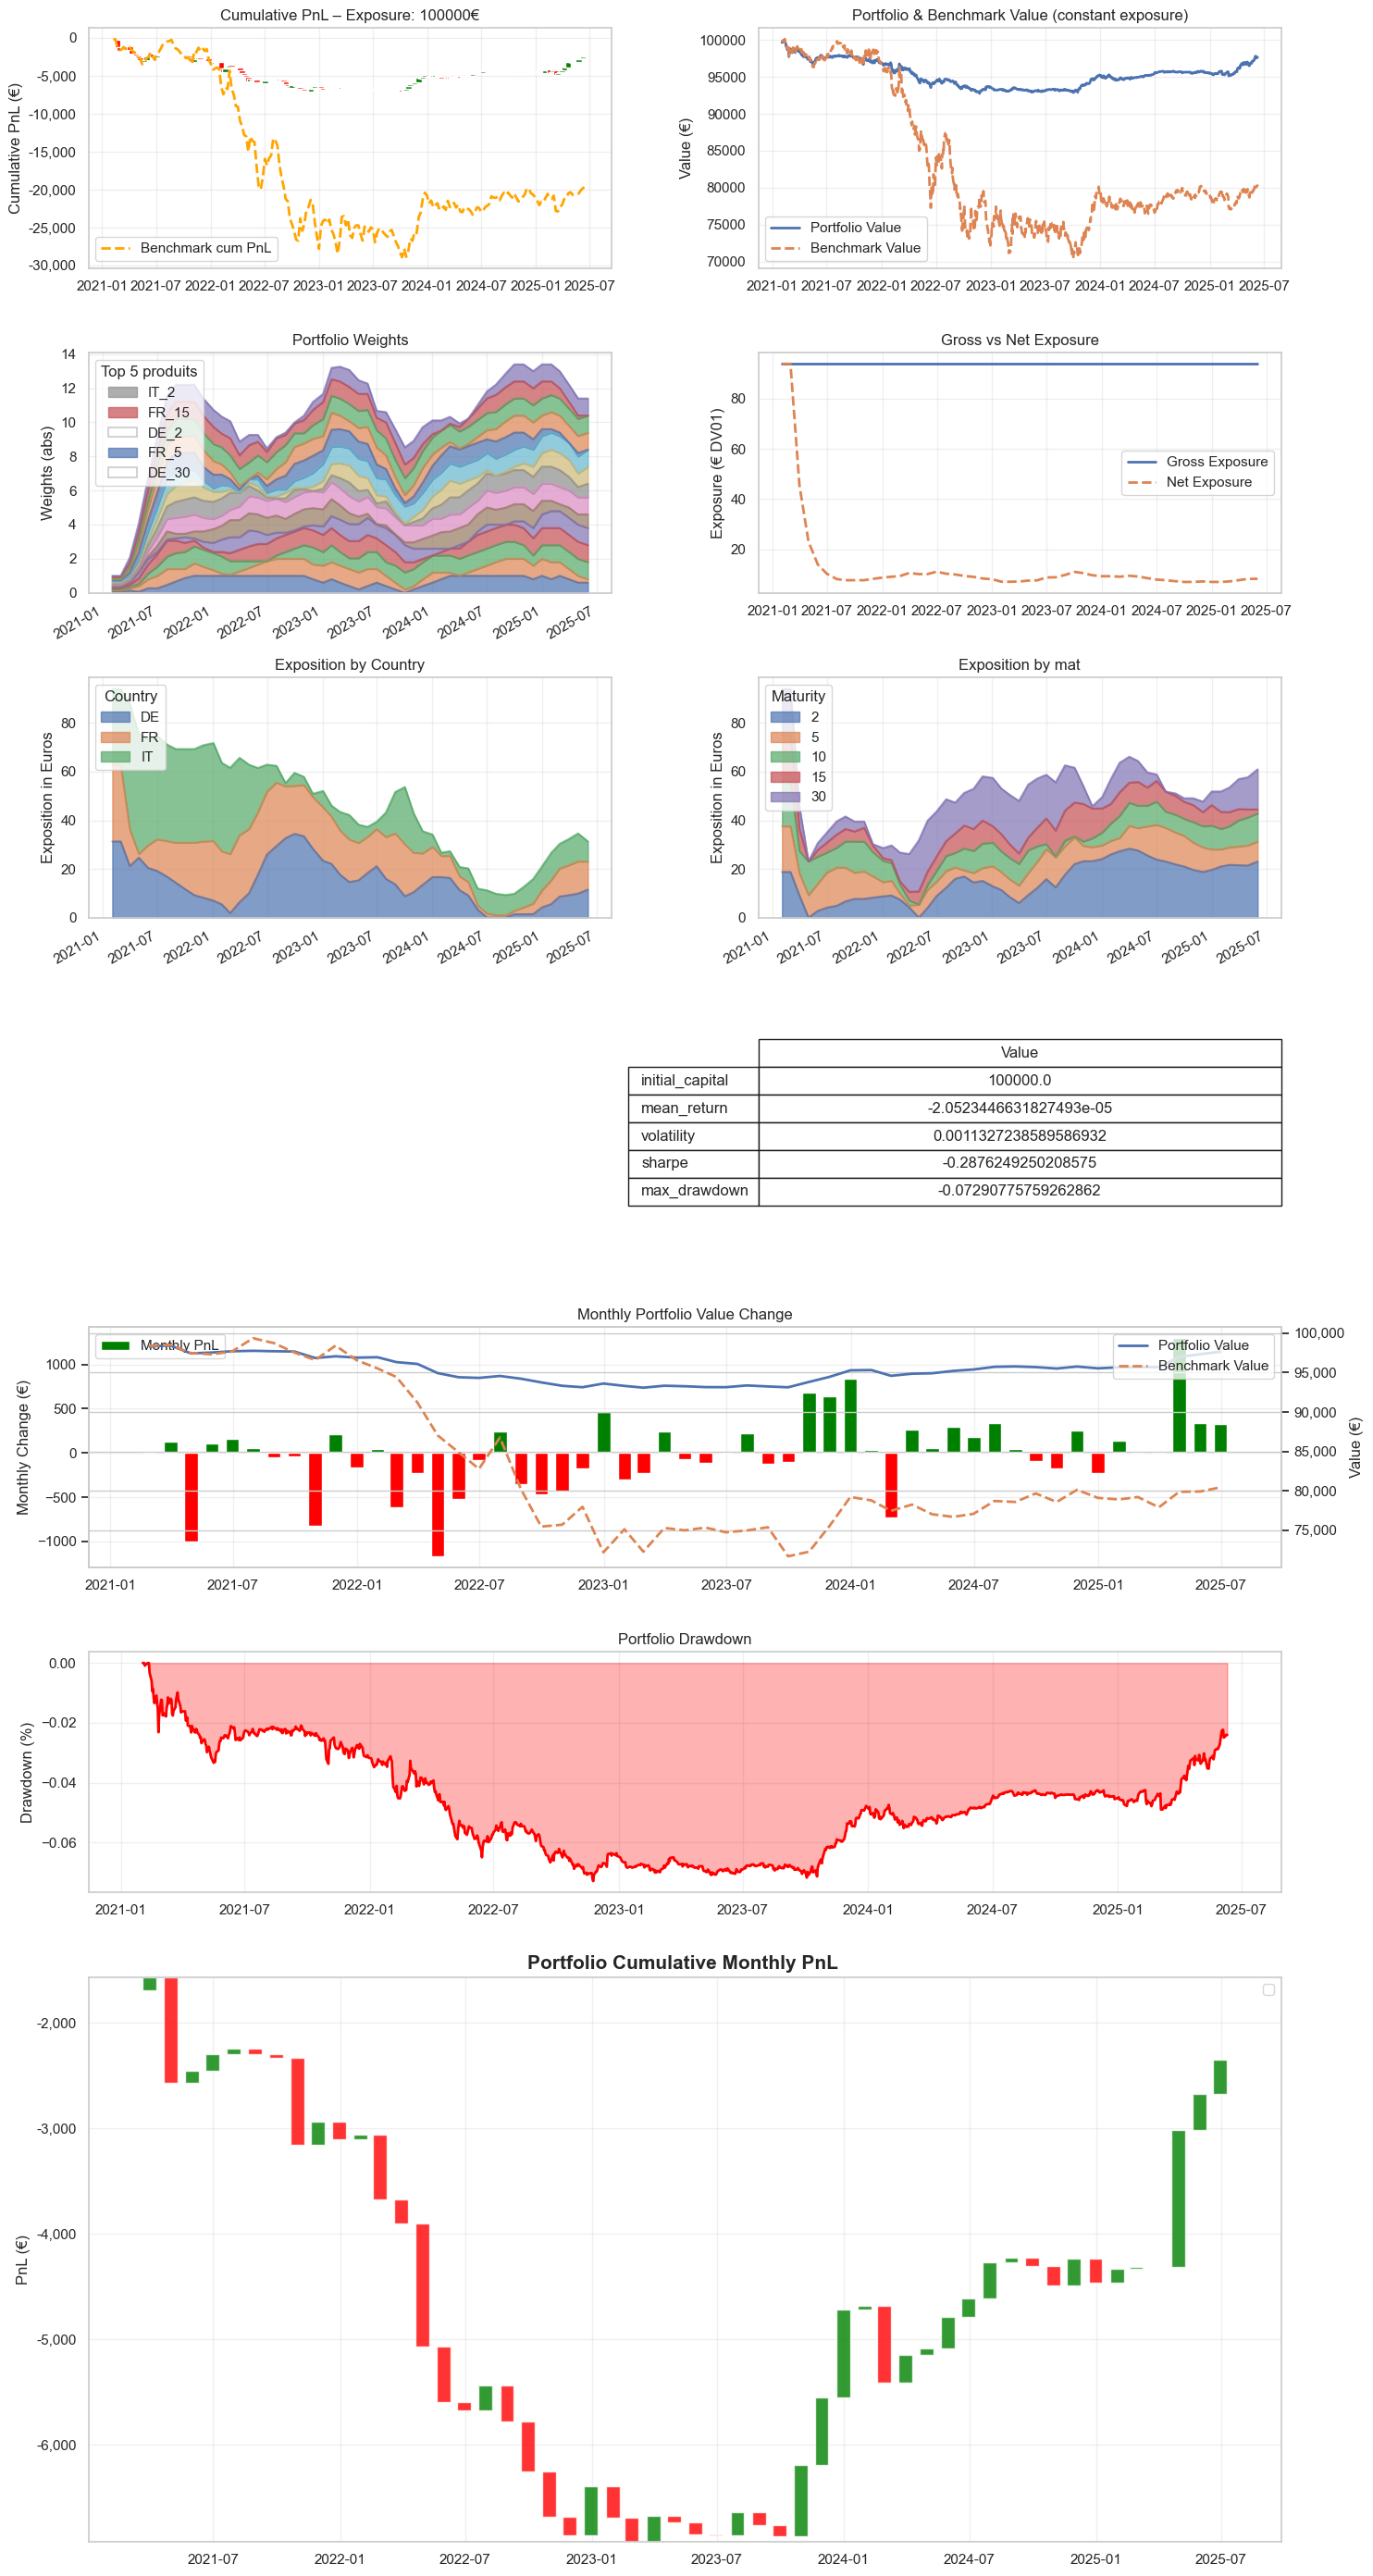

In [21]:
start_date = "2021-01-01"
end_date   = "2025-06-10"


tspf = TimeSeriesPortfolio(
    data=long_bond,
    start_date="2021-01-01",
    end_date="2025-06-10",
    rebalance_freq="1M",
    long_only=False,
    lamb=0.05,
    span=15,
    tc_gamma=0.08  # intensité des coûts dans l’optimisation
    #initial_weights= df_weights["weight"]
)
tspf.dv01_by_product = dv01_by_product


tspf.generate_portfolios()

viz = PortfolioDashboardVisualizer(tspf)

viz.plot_dashboard()


